#### Process Avana Log2FC data for Brunello hits

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
exec(open("../_03_01_function_to_normalize_sgrna_lfc.py").read())

In [16]:
# Find the cell line ID for A-375
cell_line_id = pd.read_csv("../../data/hits_change_data/ScreenSequenceMap_25Q3_03022025.csv")
cell_line_id = cell_line_id[(cell_line_id["ModelID"] == "ACH-000219") & (cell_line_id["Library"] == "Avana")]

selected_sequence_id = cell_line_id["SequenceID"].to_list()
selected_sequence_id

['A375-311cas9-RepA-p6_Avana-3',
 'A375-311cas9-RepB-p6_Avana-3',
 'A375RPMI-311cas9-RepA-p6_Avana-4',
 'A375RPMI-311cas9-RepB-p6_Avana-4']

In [ ]:
lfc_data = pd.read_csv("../../data/sgrna_lfc_data/avana_data/AvanaLogfoldChange_25Q2.csv")
lfc_data = lfc_data.rename(columns={lfc_data.columns[0]: 'spacer'})

# select specific columns
# lfc_data = lfc_data.iloc[:, :3]
lfc_data.head(15)

,spacer,Colo699-311cas9-RepA-p6_Avana-4,Colo699-311cas9-RepB-p6_Avana-4,HSB-2-311cas9_RepA_p4_Avana-3,HSB-2-311cas9_RepB_p4_Avana-3,NCIH1339-311Cas9_RepA_p6_Avana-3,NCIH1339-311Cas9_RepB_p6_Avana-3,HEL-311Cas9_RepA_p4_Avana-3,HEL-311Cas9_RepB_p4_Avana-3,HEL9217-311Cas9_RepA_p6_Avana-3,...,SNU977-311Cas9-AVANA-RepA-p6_Avana-4,SNU977-311Cas9-AVANA-RepB-p6_Avana-4,HMMME-311cas9-RepA-p6_Avana-4,HMMME-311cas9-RepB-p6_Avana-4,JVE528-311cas9-RepB-p6_Avana-4,UACC3133-311Cas9-RepB-P6_Avana-4,LU139-311cas9-RepB-p5_Avana-4,UPMM3-311cas9-RepA-p4_Avana-4,UACC3199-311cas9-RepA-p4_Avana-4,UACC3199-311cas9-RepB-p4_Avana-4
0,AAAAAAATCCAGCAATGCAG,-0.171066,0.029490,0.069540,0.162750,0.237938,0.229052,-0.173349,0.156643,0.107993,...,-0.433790,-0.709138,-0.580378,-0.268531,0.058415,-0.033800,-0.085320,-0.644091,-0.174569,-0.096824
1,AAAAAACCCGTAGATAGCCT,-0.402138,-0.307266,-0.313058,-0.433916,-0.572646,-0.556764,-0.705799,-0.314606,-0.209826,...,-0.563867,-0.484689,0.159082,-0.080677,-0.283203,-0.743975,-0.155078,-0.690596,-0.232494,-0.472361
2,AAAAAAGAAGAAAAAACCAG,-0.410449,-0.612478,-0.212222,0.136822,-0.588377,-0.974504,0.459130,0.696312,0.176283,...,-0.891883,-0.020638,-1.392148,-1.293585,-0.268365,0.607852,-1.211994,-0.030394,0.071135,-0.128212
3,AAAAAAGCTCAAGAAGGAGG,-0.391271,-0.523115,-0.747823,-0.443279,-0.652751,0.126859,-0.867980,-0.185511,0.051901,...,-0.501404,-0.422998,0.219032,-0.162117,-0.621547,0.068720,-0.918813,-0.843293,-0.216612,-0.447530
4,AAAAAAGGCTGTAAAAGCGT,-0.529545,-0.078421,-0.177395,-0.709120,-0.063580,-0.467151,0.234004,-0.271095,0.193193,...,-0.972852,-0.260724,0.118860,0.248156,-0.121191,0.053813,-0.300063,-0.188982,0.218309,0.120868
5,AAAAAAGGGCTCCAAAAAGG,-0.597079,0.196256,-0.442051,-0.489512,-0.207339,-0.239894,-0.875915,0.084434,-0.153561,...,-0.080975,-0.083456,-0.711989,-0.899371,0.318502,0.024631,-0.358011,-0.006433,0.467287,0.005282
6,AAAAACAACACATCAGAGCG,0.381416,-0.204037,-0.303099,-0.172987,0.136454,-0.488989,0.407917,0.625015,-0.043604,...,-1.471265,-0.578224,0.142722,0.101824,-0.295583,0.101226,0.830775,0.152045,0.135000,-0.275124
7,AAAAACTCTGGGAAATGACT,0.334391,0.231206,0.208982,-0.238882,-0.247617,0.030078,0.372719,0.573196,0.025043,...,-0.252516,0.023167,0.348881,0.520460,-0.340950,-0.240883,0.145043,0.258763,0.080839,-0.062581
8,AAAAAGACAACCTCGCCCTG,0.108744,0.099787,0.444292,0.007283,-0.231494,0.242598,-0.699215,0.081067,0.227647,...,-0.539427,0.338899,-0.554798,-0.266942,-0.016523,-0.214951,0.204190,-0.200871,-0.086072,-0.028628
9,AAAAAGAGCTGTTTGAACAA,-0.084525,0.066873,-0.253916,0.098424,0.055886,0.177427,0.056252,-0.018906,0.108850,...,0.447708,0.405770,0.034198,0.355359,-0.121250,0.173787,0.590183,0.087866,-0.021700,0.248652


In [5]:
library_data = pd.read_csv("../../data/library_data/original_library/avana_library.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
library_data.shape

(71826, 3)

In [6]:
lfc = pd.merge(lfc_data, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="gene")
lfc

Colo699-311cas9-RepA-p6_Avana-4  \
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.257686   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.233408   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                         0.023756   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                         0.014280   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                         0.054652   
...                                                             ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                         -0.347602   
         TTTTACCTTGTTCACATGGA NaN                          0.085937   
         TTTTGACTCTAATCACCGGT NaN                          0.004612   
         TTTTTAATACAAGGTAATCT NaN                         -0.007124   
         TTTTTCTCACCCGATGAATC NaN                          0.033292   

                                    Colo699-311cas9-RepB-p6_Avana-4  \
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.298174   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.299895   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                        -0.473843   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                        -0.324734   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                        -0.087523   
...                                                             ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                          0.320081   
         TTTTACCTTGTTCACATGGA NaN                          0.292619   
         TTTTGACTCTAATCACCGGT NaN                         -0.385894   
         TTTTTAATACAAGGTAATCT NaN                          0.154439   
         TTTTTCTCACCCGATGAATC NaN                         -0.138348   

                                    HSB-2-311cas9_RepA_p4_Avana-3  \
sgRNA    spacer               gene                                  
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                       0.226088   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                       0.425173   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                      -0.419967   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                       0.235696   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      -0.405659   
...                                                           ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                       -0.042124   
         TTTTACCTTGTTCACATGGA NaN                        0.207097   
         TTTTGACTCTAATCACCGGT NaN                        0.182117   
         TTTTTAATACAAGGTAATCT NaN                       -0.221927   
         TTTTTCTCACCCGATGAATC NaN                       -0.256905   

                                    HSB-2-311cas9_RepB_p4_Avana-3  \
sgRNA    spacer               gene                                  
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                       0.030155   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                       0.251597   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                      -0.159187   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                      -0.686056   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      -0.322912   
...                                                           ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                       -0.290717   
         TTTTACCTTGTTCACATGGA NaN                        0.210888   
         TTTTGACTCTAATCACCGGT NaN                        0.221753   
         TTTTTAATACAAGGTAATCT NaN                       -0.152003   
         TTTTTCTCACCCGATGAATC NaN                       -0.251676   

                                    NCIH1339-311Cas9_RepA_p6_Avana-3  \
sgRNA    spacer               gene                                     
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                          0.195384   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         -0.004233   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                          0.235672   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1

In [18]:
selected_lfc = lfc[selected_sequence_id]
selected_lfc

A375-311cas9-RepA-p6_Avana-3  \
sgRNA    spacer               gene                                 
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                      0.013599   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                      0.197074   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                     -0.077917   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                      0.294072   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      0.493136   
...                                                          ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                      -0.242586   
         TTTTACCTTGTTCACATGGA NaN                       0.568153   
         TTTTGACTCTAATCACCGGT NaN                       0.526010   
         TTTTTAATACAAGGTAATCT NaN                       0.655309   
         TTTTTCTCACCCGATGAATC NaN                       0.531988   

                                    A375-311cas9-RepB-p6_Avana-3  \
sgRNA    spacer               gene                                 
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                     -0.119954   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                      0.067245   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                     -0.092885   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                      0.189205   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      0.447127   
...                                                          ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                       0.238602   
         TTTTACCTTGTTCACATGGA NaN                       1.162735   
         TTTTGACTCTAATCACCGGT NaN                       0.948708   
         TTTTTAATACAAGGTAATCT NaN                       0.500642   
         TTTTTCTCACCCGATGAATC NaN                       0.687321   

                                    A375RPMI-311cas9-RepA-p6_Avana-4  \
sgRNA    spacer               gene                                     
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                         -0.318118   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         -0.563434   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                          0.114101   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                          0.142639   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                          0.203094   
...                                                              ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                          -0.065709   
         TTTTACCTTGTTCACATGGA NaN                           0.577683   
         TTTTGACTCTAATCACCGGT NaN                           0.692550   
         TTTTTAATACAAGGTAATCT NaN                           0.697090   
         TTTTTCTCACCCGATGAATC NaN                           0.629483   

                                    A375RPMI-311cas9-RepB-p6_Avana-4  
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                         -0.738133  
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         -0.302219  
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                         -0.033516  
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                          0.317846  
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                          0.115496  
...                                                              ...  
NaN      TTTGTGTATTACCTCAGGAA NaN                          -1.284066  
         TTTTACCTTGTTCACATGGA NaN                           0.318303  
         TTTTGACTCTAATCACCGGT NaN                          -0.177083  
         TTTTTAATACAAGGTAATCT NaN                           0.741100  
         TTTTTCTCACCCGATGAATC NaN                           0.545674  

[76427 rows x 4 columns]

In [21]:
# normalize data by median
lfc_norm = lfc.apply(normalize_column, axis=0)

Scale factor:  1.617693797866464


<string>:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


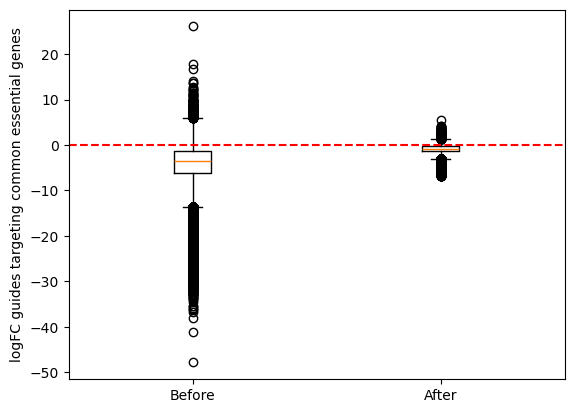

In [24]:
lfc_norm_scaled, list_common_essential = scale_essential(lfc, "../../data/hits_change_data/constitutive_core_essential_hart_2014.csv")
sanity_check_scale_essential(lfc_norm, lfc_norm_scaled, list_common_essential)

In [25]:
lfc_norm_scaled_avg = mean_row(lfc_norm_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,GGAAGTCTGGAGTCTCCAGG,A1BG,0.000025
1,sgA1BG_2,GTGGACTTCCAGCTACGGCG,A1BG,0.185000
2,sgA1BG_4,TCAATGGTCACAGTAGCGCT,A1BG,-0.068658
3,sgA1BG_3,GTGTGCCGAGGTGTGCTGCG,A1BG,0.039300
4,sgA1CF_2,GGAATCAAATCACAAATCCG,A1CF,-0.074092
...,...,...,...,...
76422,NaN,TTTGTGTATTACCTCAGGAA,NaN,0.011669
76423,NaN,TTTTACCTTGTTCACATGGA,NaN,0.256892
76424,NaN,TTTTGACTCTAATCACCGGT,NaN,0.132699
76425,NaN,TTTTTAATACAAGGTAATCT,NaN,0.189791


In [27]:
lfc_norm_scaled_avg.to_csv("../../data/sgrna_lfc_data/output_normalized/avana_A375_normalized_lfc.csv", index=False)